# Molecular Graphs and Adjacency Matrices



---

## 0. Setup

Only NumPy is required for the core of this notebook. Matplotlib and NetworkX are used for pictures,
and RDKit appears only in the optional Section 9.

In [ ]:
import numpy as np
from collections import deque

np.set_printoptions(linewidth=140)

# Optional plotting libraries (skip silently if unavailable)
try:
    import matplotlib.pyplot as plt
    HAVE_PLT = True
except ImportError:
    HAVE_PLT = False
    print("matplotlib not found - plots will be skipped")

try:
    import networkx as nx
    HAVE_NX = True
except ImportError:
    HAVE_NX = False
    print("networkx not found - graph drawings will be skipped")

print("NumPy", np.__version__)

NumPy 2.0.2


## 1. What is a molecular graph?

Strip a molecule of all its geometry — bond lengths, angles, torsions — and keep only the question
*"which atom is bonded to which?"*. What remains is a **graph** $G=(V,E)$:

* **vertices** $V$ = atoms (numbered $0, 1, \dots, N-1$),
* **edges** $E$ = bonds.

The **adjacency matrix** $\mathbf{A}$ is the $N \times N$ matrix

$$
A_{ij} =
\begin{cases}
1 & \text{if atoms } i \text{ and } j \text{ are bonded},\\
0 & \text{otherwise},
\end{cases}
\qquad A_{ii}=0 .
$$

Three properties follow immediately, and you should be able to state why:

* $\mathbf{A}$ is **symmetric** ($A_{ij}=A_{ji}$) — a bond has no direction.
* The **diagonal is zero** — an atom is not bonded to itself.
* $\sum_j A_{ij}$ is the number of neighbours of atom $i$ — its **degree**, which for a
  closed-shell organic molecule is its **valence**.

### Warm-up: water by hand

Number the atoms $0=\mathrm{O}$, $1=\mathrm{H}$, $2=\mathrm{H}$. The bonds are $(0,1)$ and $(0,2)$, so

$$
\mathbf{A}(\mathrm{H_2O}) =
\begin{pmatrix}
0 & 1 & 1\\
1 & 0 & 0\\
1 & 0 & 0
\end{pmatrix}
$$

Note there is **no** entry connecting atom 1 and atom 2: the two hydrogens are not bonded to each other,
even though they are only 1.5 Å apart. Being close in space is not the same as being bonded — a
distinction Section 4 will make you work for.

In [ ]:
A_water = np.array([[0, 1, 1],
                    [1, 0, 0],
                    [1, 0, 0]])

print(A_water)
print("symmetric? ", np.array_equal(A_water, A_water.T))
print("zero diagonal?", np.all(np.diag(A_water) == 0))
print("degrees:      ", A_water.sum(axis=1))   # O has 2 neighbours, each H has 1

[[0 1 1]
 [1 0 0]
 [1 0 0]]
symmetric?  True
zero diagonal? True
degrees:       [2 1 1]


> **Numbering is arbitrary, chemistry is not.** If you relabel the atoms you get a *different*
> matrix that describes the *same* molecule. Formally, $\mathbf{A}' = \mathbf{P}\mathbf{A}\mathbf{P}^{\mathsf{T}}$
> for a permutation matrix $\mathbf{P}$. Anything you compute from $\mathbf{A}$ and claim to be a
> molecular property must be invariant under such a relabelling — the eigenvalues are, the individual
> matrix elements are not. This is exactly why graph neural networks are built to be permutation
> equivariant.

## 2. From a bond list to a matrix

Writing matrices by hand gets old fast. In practice you keep a **bond list** — the chemist's natural
representation — and generate $\mathbf{A}$ from it.

In [ ]:
def adjacency_from_bonds(n_atoms, bonds):
    """Build a binary adjacency matrix from a list of (i, j) bonds."""
    A = np.zeros((n_atoms, n_atoms), dtype=int)
    for i, j in bonds:
        A[i, j] = 1
        A[j, i] = 1          # symmetry: always set both
    return A


def bonds_from_adjacency(A):
    """Inverse operation: recover the unique (i, j) bond list, i < j."""
    n = len(A)
    return [(i, j) for i in range(n) for j in range(i + 1, n) if A[i, j]]

Here is a small library of molecules stored as `(symbols, bonds)`. Note the convention used
throughout this notebook: **heavy atoms first, then hydrogens**. That is not required, but it makes
hydrogen suppression (Section 5) trivial.

In [ ]:
MOLECULES = {
    # name: (list of element symbols, list of (i, j) bonds)
    "water":     (["O", "H", "H"],
                  [(0, 1), (0, 2)]),

    "methane":   (["C", "H", "H", "H", "H"],
                  [(0, 1), (0, 2), (0, 3), (0, 4)]),

    "ethanol":   (["C", "C", "O", "H", "H", "H", "H", "H", "H"],
                  [(0, 1), (1, 2),                       # C-C, C-O
                   (0, 3), (0, 4), (0, 5),               # methyl H
                   (1, 6), (1, 7),                       # methylene H
                   (2, 8)]),                             # hydroxyl H

    "benzene":   (["C"] * 6 + ["H"] * 6,
                  [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)] +
                  [(k, k + 6) for k in range(6)]),

    "cyclohexane": (["C"] * 6 + ["H"] * 12,
                    [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)] +
                    [(k, 6 + 2 * k) for k in range(6)] +
                    [(k, 7 + 2 * k) for k in range(6)]),

    "acetic acid": (["C", "C", "O", "O", "H", "H", "H", "H"],
                    [(0, 1), (1, 2), (1, 3),             # C-C, C=O, C-O
                     (0, 4), (0, 5), (0, 6),             # methyl H
                     (3, 7)]),                           # O-H
}

symbols, bonds = MOLECULES["ethanol"]
A_ethanol = adjacency_from_bonds(len(symbols), bonds)

print("ethanol,", len(symbols), "atoms,", len(bonds), "bonds")
print(A_ethanol)
print("recovered bond list:", bonds_from_adjacency(A_ethanol))

ethanol, 9 atoms, 8 bonds
[[0 1 0 1 1 1 0 0 0]
 [1 0 1 0 0 0 1 1 0]
 [0 1 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0]]
recovered bond list: [(0, 1), (0, 3), (0, 4), (0, 5), (1, 2), (1, 6), (1, 7), (2, 8)]


A labelled printout is far easier to read than a bare NumPy array, so let us make one.

In [ ]:
def show_matrix(A, symbols, title=""):
    """Pretty-print an adjacency matrix with atom labels like C0, C1, O2, H3 ..."""
    labels = [f"{s}{i}" for i, s in enumerate(symbols)]
    if title:
        print(title)
    print("      " + " ".join(f"{l:>4s}" for l in labels))
    for lab, row in zip(labels, np.asarray(A)):
        cells = " ".join(f"{v:4.0f}" if v else "   ." for v in row)
        print(f"{lab:>5s} {cells}")
    print()


show_matrix(A_ethanol, MOLECULES["ethanol"][0], "Ethanol - adjacency matrix")

Ethanol - adjacency matrix
        C0   C1   O2   H3   H4   H5   H6   H7   H8
   C0    .    1    .    1    1    1    .    .    .
   C1    1    .    1    .    .    .    1    1    .
   O2    .    1    .    .    .    .    .    .    1
   H3    1    .    .    .    .    .    .    .    .
   H4    1    .    .    .    .    .    .    .    .
   H5    1    .    .    .    .    .    .    .    .
   H6    .    1    .    .    .    .    .    .    .
   H7    .    1    .    .    .    .    .    .    .
   H8    .    .    1    .    .    .    .    .    .



Read the ethanol matrix row by row and check it against the structure `CH3-CH2-OH`. Row `C0` has four
ones (three H plus C1); row `C1` has four (C0, O2, two H); row `O2` has two (C1 and H8). Every
hydrogen row has exactly one. **The row sums are the valences** — this is your first, and cheapest,
sanity check on any structure you build.

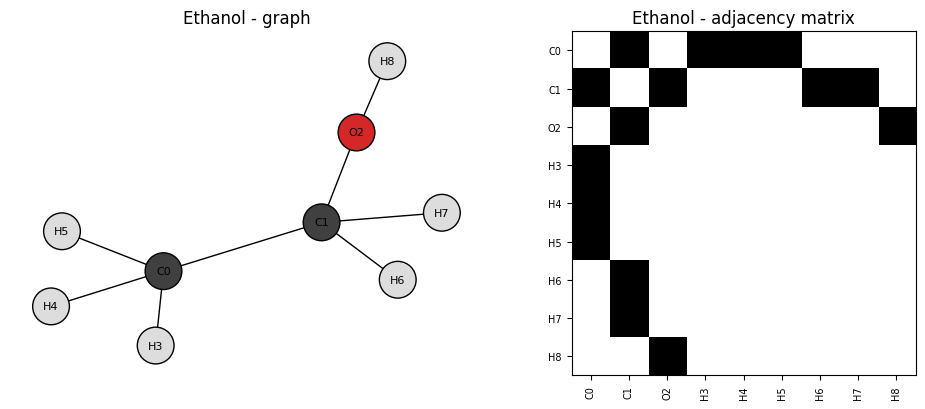

In [ ]:
# --- optional: draw the graph -------------------------------------------------
def draw_molecule_graph(A, symbols, title="", seed=3):
    if not (HAVE_NX and HAVE_PLT):
        print("networkx/matplotlib unavailable - skipping drawing")
        return
    G = nx.from_numpy_array(np.asarray(A))
    colours = {"C": "#404040", "H": "#dddddd", "O": "#d62728",
               "N": "#1f77b4", "S": "#e2c044", "F": "#2ca02c"}
    node_colour = [colours.get(s, "#9467bd") for s in symbols]
    labels = {i: f"{s}{i}" for i, s in enumerate(symbols)}

    fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, ax=ax[0], node_color=node_colour, labels=labels,
            with_labels=True, node_size=700, edgecolors="black", font_size=8)
    ax[0].set_title(f"{title} - graph")

    ax[1].imshow(np.asarray(A), cmap="Greys", vmin=0, vmax=1)
    ticks = range(len(symbols))
    ax[1].set_xticks(ticks); ax[1].set_yticks(ticks)
    ax[1].set_xticklabels([f"{s}{i}" for i, s in enumerate(symbols)], fontsize=7, rotation=90)
    ax[1].set_yticklabels([f"{s}{i}" for i, s in enumerate(symbols)], fontsize=7)
    ax[1].set_title(f"{title} - adjacency matrix")
    plt.tight_layout(); plt.show()


draw_molecule_graph(A_ethanol, MOLECULES["ethanol"][0], "Ethanol")

### Exercise 1 — build a matrix from a structure

Propan-2-ol, `(CH3)2CH-OH`, has 12 atoms. Using the ordering
`C0, C1, C2, O3` for the heavy atoms (C1 is the central carbon) followed by hydrogens `H4 ... H11`,
complete the bond list below, build the matrix, and verify every valence.

In [ ]:
# Exercise 1
symbols_2propanol = ["C", "C", "C", "O"] + ["H"] * 8

bonds_2propanol = [
    # TODO: heavy-atom skeleton - C0-C1, C1-C2, C1-O3
    # TODO: three H on C0, three H on C2, one H on C1, one H on O3
]

# A_2propanol = adjacency_from_bonds(len(symbols_2propanol), bonds_2propanol)
# show_matrix(A_2propanol, symbols_2propanol, "Propan-2-ol")
# print("degrees:", A_2propanol.sum(axis=1))
# Expected degrees: C 4, C 4, C 4, O 2, then eight 1s

### Exercise

Translating a structural formula into a bond list is the one skill in this notebook you should be
able to do without a computer, so here is a graded set of them. The checker below marks your work
automatically: it verifies that every atom reaches its **standard valence**, that the molecule is in
one piece, and that the molecular formula and ring count come out right.

Because several of these molecules contain multiple bonds, the drill uses `(i, j, order)` triples
rather than plain `(i, j)` pairs — a double bond contributes 2 to an atom's valence but only one
edge to the graph. Getting the binary adjacency matrix from the triples is then trivial.

In [ ]:
from collections import Counter

STANDARD_VALENCE = {"H": 1, "C": 4, "N": 3, "O": 2, "S": 2,
                    "F": 1, "Cl": 1, "Br": 1, "I": 1, "P": 3}


def molecular_formula(symbols):
    '''Hill notation: C first, then H, then everything else alphabetically.'''
    counts = Counter(symbols)
    out = ""
    for element in ["C", "H"]:
        if counts[element]:
            out += element + (str(counts[element]) if counts[element] > 1 else "")
            del counts[element]
    for element in sorted(counts):
        out += element + (str(counts[element]) if counts[element] > 1 else "")
    return out


def _count_fragments(A):
    '''Breadth-first fragment count. Section 3 derives this properly.'''
    n = len(A)
    seen, n_frag = set(), 0
    for start in range(n):
        if start in seen:
            continue
        n_frag += 1
        queue = deque([start]); seen.add(start)
        while queue:
            v = queue.popleft()
            for w in range(n):
                if A[v][w] and w not in seen:
                    seen.add(w); queue.append(w)
    return n_frag


def check_structure(symbols, bonds_with_order, name="", expected_formula=None,
                    expected_rings=None, verbose=True):
    '''Mark a hand-built structure: valences, connectivity, formula, ring count.'''
    n = len(symbols)
    A = np.zeros((n, n))
    problems = []

    for i, j, order in bonds_with_order:
        if i == j:
            problems.append(f"atom {i} is bonded to itself")
        A[i, j] = A[j, i] = order

    valence = A.sum(axis=1)
    for i, s in enumerate(symbols):
        expected = STANDARD_VALENCE.get(s)
        if expected is not None and abs(valence[i] - expected) > 1e-9:
            problems.append(f"{s}{i} has valence {valence[i]:g}, expected {expected}")

    A_binary = (A > 0).astype(int)
    n_frag = _count_fragments(A_binary)
    if n_frag != 1:
        problems.append(f"{n_frag} disconnected fragments - a bond is missing")

    formula = molecular_formula(symbols)
    if expected_formula and formula != expected_formula:
        problems.append(f"formula is {formula}, expected {expected_formula}")

    n_edges = int(A_binary.sum() // 2)
    rings = n_edges - n + n_frag              # Euler formula, derived in Section 6
    if expected_rings is not None and rings != expected_rings:
        problems.append(f"{rings} ring(s), expected {expected_rings}")

    if verbose:
        verdict = "PASS" if not problems else "FAIL"
        print(f"{name:16s} {formula:10s} {verdict}   "
              f"atoms={n}  bonds={len(bonds_with_order)}  rings={rings}")
        for p in problems:
            print("    -", p)
    return not problems


# Demonstration on a structure you have already seen
check_structure(MOLECULES["acetic acid"][0],
                [(0, 1, 1), (1, 2, 2), (1, 3, 1), (0, 4, 1), (0, 5, 1), (0, 6, 1), (3, 7, 1)],
                name="acetic acid", expected_formula="C2H4O2", expected_rings=0)

acetic acid      C2H4O2     PASS   atoms=8  bonds=7  rings=0


True

#### Exercise 1.1 — single bonds only

Three molecules, no multiple bonds. Keep the ordering given in `symbols`: heavy atoms first, then
hydrogens in the order they are attached.

* **dimethyl ether**, `CH3-O-CH3` — note that carbons 0 and 1 are *not* bonded to each other.
* **cyclopropane**, a three-membered carbon ring with two H on each carbon.
* **ethylamine**, `CH3-CH2-NH2` — nitrogen takes three bonds, so it carries two hydrogens.

In [ ]:
# Exercise 1.1
PROBLEMS_1 = {
    "dimethyl ether": (["C", "C", "O"] + ["H"] * 6, "C2H6O", 0,
                       [
                           # TODO: C0-O2, C1-O2, then three H on each carbon
                       ]),

    "cyclopropane":   (["C"] * 3 + ["H"] * 6, "C3H6", 1,
                       [
                           # TODO: close the C0-C1-C2 ring, then two H on each carbon
                       ]),

    "ethylamine":     (["C", "C", "N"] + ["H"] * 7, "C2H7N", 0,
                       [
                           # TODO: C0-C1, C1-N2, then 3 H on C0, 2 H on C1, 2 H on N2
                       ]),
}

for name, (syms, formula, rings, bnds) in PROBLEMS_1.items():
    if bnds:
        check_structure(syms, bnds, name, formula, rings)

#### Exercise 1.2 — molecules with multiple bonds

Now the bond order starts doing work. Remember: a C=O contributes 2 to the valence of both atoms but
adds only a single 1 to the binary adjacency matrix.

* **propene**, `CH2=CH-CH3`
* **acetaldehyde**, `CH3-CHO`
* **acetone**, `(CH3)2C=O`
* **acetonitrile**, `CH3-C#N` — a triple bond
* **formic acid**, `HCOOH` — note carefully which oxygen carries the hydrogen

In [ ]:
# Exercise 1.2
PROBLEMS_2 = {
    "propene":      (["C", "C", "C"] + ["H"] * 6, "C3H6", 0,
                     [
                         # TODO: C0=C1 (order 2), C1-C2, then 2 H on C0, 1 H on C1, 3 H on C2
                     ]),

    "acetaldehyde": (["C", "C", "O"] + ["H"] * 4, "C2H4O", 0,
                     [
                         # TODO: C0-C1, C1=O2, three H on the methyl C0, one H on the carbonyl C1
                     ]),

    "acetone":      (["C", "C", "C", "O"] + ["H"] * 6, "C3H6O", 0,
                     [
                         # TODO: C1 is the carbonyl carbon, bonded to C0, C2 and doubly to O3
                     ]),

    "acetonitrile": (["C", "C", "N"] + ["H"] * 3, "C2H3N", 0,
                     [
                         # TODO: C0-C1 single, C1#N2 triple, three H on C0
                     ]),

    "formic acid":  (["C", "O", "O"] + ["H"] * 2, "CH2O2", 0,
                     [
                         # TODO: C0=O1, C0-O2, one H on C0, one H on O2
                     ]),
}

for name, (syms, formula, rings, bnds) in PROBLEMS_2.items():
    if bnds:
        check_structure(syms, bnds, name, formula, rings)

#### Exercise 1.3 — multifunctional and aromatic

For the aromatic rings, use the 1.5 convention from Section 5.1. Check that it still balances the
valences: an aromatic CH carbon gets $1.5 + 1.5 + 1 = 4$.

* **glycine**, `H2N-CH2-COOH` — the simplest amino acid, with three functional groups
* **toluene**, an aromatic ring plus a methyl substituent
* **pyridine**, where one ring carbon is replaced by nitrogen (which carries no hydrogen)

In [ ]:
# Exercise 1.3
ring6 = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)]

PROBLEMS_3 = {
    "glycine":  (["N", "C", "C", "O", "O"] + ["H"] * 5, "C2H5NO2", 0,
                 [
                     # TODO: N0-C1, C1-C2, C2=O3, C2-O4,
                     #       2 H on N0, 2 H on C1, 1 H on the hydroxyl O4
                 ]),

    "toluene":  (["C"] * 7 + ["H"] * 8, "C7H8", 1,
                 [
                     # TODO: six aromatic ring bonds at order 1.5 (use ring6),
                     #       C0-C6 methyl bond, one H on each of C1..C5, three H on C6
                 ]),

    "pyridine": (["N"] + ["C"] * 5 + ["H"] * 5, "C5H5N", 1,
                 [
                     # TODO: six aromatic ring bonds at order 1.5, one H on each carbon.
                     #       N0 gets no hydrogen - why not?
                 ]),
}

for name, (syms, formula, rings, bnds) in PROBLEMS_3.items():
    if bnds:
        check_structure(syms, bnds, name, formula, rings)